# DeepSeek Janus-Pro-7B: 100% GPU Multimodal Understanding & Text-to-Image Generation

Welcome! This notebook allows you to interactively test **[deepseek-ai/Janus-Pro-7B](https://huggingface.co/deepseek-ai/Janus-Pro-7B)** completely on your **NVIDIA GeForce RTX 5050 GPU (0% CPU offload)**.

> **Kernel Selection**: In the top right corner of this notebook, ensure your kernel is set to **`Python 3.13 (Janus GPU - RTX 5050)`**.

### Instructions
- Execute each cell sequentially from top to bottom (`Shift + Enter`).
- The model runs in 4-bit NF4 precision, consuming ~4.8 GB of VRAM and fitting 100% within your 8 GB GPU.
- In the multimodal and image generation sections, you will be prompted to enter your own prompts and images!

## 1. Hardware & CUDA Environment Verification
Verifies your RTX 5050 Laptop GPU (Blackwell `sm_120`), CUDA 12.8 support, and GPU memory.

In [1]:
import os
import sys
import torch

print(f"Python Executable: {sys.executable}")
print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU Name: {gpu_name}")
    print(f"Compute Capability: {capability} (sm_{capability[0]}{capability[1]})")
    print(f"Total GPU Memory: {total_mem:.2f} GB")
    
    # Quick test tensor execution on sm_120
    test_x = torch.ones((10, 10), device="cuda:0") * 42.0
    print(f"CUDA Kernel execution verified on GPU: {test_x[0, 0].item()}")
else:
    raise SystemError("CUDA is not available! GPU is required.")

Python Executable: c:\Users\krish\AppData\Local\Programs\Python\Python313\python.exe
Python Version: 3.13.15
PyTorch Version: 2.12.0.dev20260408+cu128
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
Compute Capability: (12, 0) (sm_120)
Total GPU Memory: 7.93 GB
CUDA Kernel execution verified on GPU: 42.0


## 2. Local Model Directory Verification
Verifies all 13 downloaded files (~13.8 GB) in `./Janus-Pro-7B`.

In [2]:
import os

local_model_dir = os.path.abspath("./Janus-Pro-7B")
downloaded_files = [f for f in os.listdir(local_model_dir) if os.path.isfile(os.path.join(local_model_dir, f))]
total_size_gb = sum(os.path.getsize(os.path.join(local_model_dir, f)) for f in downloaded_files) / (1024**3)

print(f"Local directory: {local_model_dir}")
print(f"Model files verified! {len(downloaded_files)} files found ({total_size_gb:.2f} GB total).")
for f in sorted(downloaded_files):
    f_path = os.path.join(local_model_dir, f)
    print(f"  - {f} ({os.path.getsize(f_path) / (1024**2):.1f} MB)")

Local directory: c:\codeX\learn-AI\loading_model_from_hugging_face\Janus-Pro-7B
Model files verified! 13 files found (13.83 GB total).
  - .gitattributes (0.0 MB)
  - README.md (0.0 MB)
  - config.json (0.0 MB)
  - janus_pro_teaser1.png (0.1 MB)
  - janus_pro_teaser2.png (0.5 MB)
  - preprocessor_config.json (0.0 MB)
  - processor_config.json (0.0 MB)
  - pytorch_model-00001-of-00002.bin (9525.5 MB)
  - pytorch_model-00002-of-00002.bin (4628.2 MB)
  - pytorch_model.bin.index.json (0.1 MB)
  - special_tokens_map.json (0.0 MB)
  - tokenizer.json (4.5 MB)
  - tokenizer_config.json (0.0 MB)


## 3. Load Janus-Pro-7B on GPU (4-Bit NF4 Quantization)
Loads the processor and model directly onto `cuda:0` with 0% CPU offload.

In [3]:
import sys
sys.path.insert(0, os.path.abspath("./Janus"))

import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from janus.models import MultiModalityCausalLM, VLChatProcessor
from janus.utils.io import load_pil_images

model_path = os.path.abspath("./Janus-Pro-7B")

# 4-bit NF4 Quantization config (fits ~4.8 GB into 8 GB VRAM)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading VLChatProcessor from local folder...")
vl_chat_processor = VLChatProcessor.from_pretrained(model_path)
tokenizer = vl_chat_processor.tokenizer

print("Loading MultiModalityCausalLM on cuda:0 in 4-bit NF4...")
vl_gpt = AutoModelForCausalLM.from_pretrained(
    model_path,
    trust_remote_code=True,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="cuda:0"
)
vl_gpt = vl_gpt.eval()

alloc_gb = torch.cuda.memory_allocated(0) / (1024**3)
res_gb = torch.cuda.memory_reserved(0) / (1024**3)
print(f"\nModel loaded successfully 100% on GPU!")
print(f"GPU VRAM Allocated: {alloc_gb:.2f} GB | Reserved: {res_gb:.2f} GB")

Python version is above 3.10, patching the collections module.


c:\Users\krish\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\auto\image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it mean

Loading VLChatProcessor from local folder...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading MultiModalityCausalLM on cuda:0 in 4-bit NF4...


W0922 11:44:50.891000 37000 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Model loaded successfully 100% on GPU!
GPU VRAM Allocated: 4.85 GB | Reserved: 5.37 GB


## 4. Parameter Device Audit (Verify Zero CPU Offload)
Checks that 100% of parameter tensors reside on `cuda:0` and 0 on CPU.

In [4]:
cpu_count = 0
gpu_count = 0

for name, param in vl_gpt.named_parameters():
    if param.device.type == "cpu":
        cpu_count += 1
    elif param.device.type == "cuda":
        gpu_count += 1

print("=== Parameter Placement Audit ===")
print(f"Parameters on GPU (cuda:0): {gpu_count}")
print(f"Parameters on CPU:          {cpu_count}")

if cpu_count == 0 and gpu_count > 0:
    print("SUCCESS: 100% of model parameters reside strictly on GPU (0% CPU offload)!")
else:
    raise AssertionError(f"Audit failed: {cpu_count} parameters found on CPU!")

=== Parameter Placement Audit ===
Parameters on GPU (cuda:0): 936
Parameters on CPU:          0
SUCCESS: 100% of model parameters reside strictly on GPU (0% CPU offload)!


## 5. Interactive Multimodal Understanding (Visual Question Answering)
Provide an image and ask any question about it.


Input Image: c:\codeX\learn-AI\loading_model_from_hugging_face\test_sample_image.png
Question: Describe this image in detail and identify all visible objects, shapes, colors, and layout.


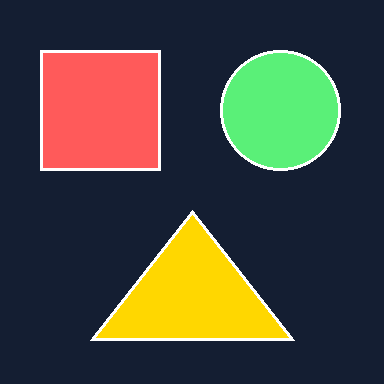


Running multimodal inference on GPU...

=== Multimodal Understanding Output ===
 This image features three distinct shapes, each with a unique color and layout.

1. **Top Left**: A red square with a white border.
2. **Top Right**: A green circle with a white border.
3. **Bottom**: A yellow triangle with a white border.

The background is dark, likely black, which contrasts with the bright colors of the shapes, making them stand out clearly.


In [5]:
from PIL import Image
from IPython.display import display

# Enter image path and question (or press Enter to use defaults)
image_input = input("Enter image path (leave blank for 'test_sample_image.png'): ").strip()
image_path = os.path.abspath(image_input) if image_input else os.path.abspath("./test_sample_image.png")

question_input = input("Enter your question about this image (leave blank for default): ").strip()
question = question_input if question_input else "Describe this image in detail and identify all visible objects, shapes, colors, and layout."

print(f"\nInput Image: {image_path}")
print(f"Question: {question}")
display(Image.open(image_path))

# Format conversation
conversation = [
    {
        "role": "User",
        "content": f"<image_placeholder>\n{question}",
        "images": [image_path],
    },
    {"role": "Assistant", "content": ""},
]

pil_images = load_pil_images(conversation)
prepare_inputs = vl_chat_processor(
    conversations=conversation,
    images=pil_images,
    force_batchify=True
).to("cuda:0", dtype=torch.bfloat16)

inputs_embeds = vl_gpt.prepare_inputs_embeds(**prepare_inputs)

print("\nRunning multimodal inference on GPU...")
with torch.no_grad():
    outputs = vl_gpt.language_model.generate(
        inputs_embeds=inputs_embeds,
        attention_mask=prepare_inputs.attention_mask,
        pad_token_id=tokenizer.eos_token_id,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        max_new_tokens=256,
        do_sample=False,
        use_cache=True,
    )

answer = tokenizer.decode(outputs[0].cpu().tolist(), skip_special_tokens=True)
print("\n=== Multimodal Understanding Output ===")
print(answer)

## 6. Interactive Text-to-Image Generation
Enter any prompt, and Janus-Pro-7B will autoregressively generate 576 visual tokens on GPU and decode them into a 384x384 image using the VQ-16 visual decoder.


Prompt: 'Rustic cabin in an idyllic alpine valley surrounded by a dense fir and spruce forest. A clear turquoise river runs past the cabin, with majestic snow-capped mountains towering in the background under a soft golden hour sunset'
Generating image on GPU...
Generating 576 visual tokens on GPU...


Visual Tokens: 100%|██████████| 576/576 [00:32<00:00, 17.58it/s]



Decoding visual tokens with VQ-16 decoder on GPU...

Image saved to: c:\codeX\learn-AI\loading_model_from_hugging_face\output_images\user_generated_image.png
Generated Result:


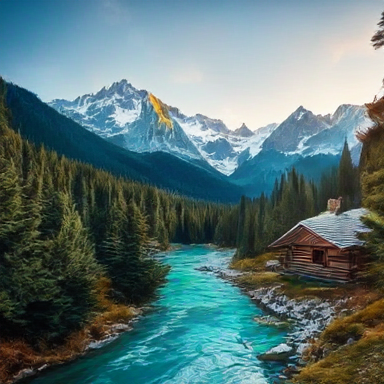

In [9]:
from tqdm import tqdm
import numpy as np
from PIL import Image
from IPython.display import display

os.makedirs("./output_images", exist_ok=True)
output_img_path = os.path.abspath("./output_images/user_generated_image.png")

# Ask for prompt
custom_prompt = input("Enter your image prompt (or press Enter for default): ").strip()
prompt = custom_prompt if custom_prompt else "A beautiful neon cybernetic cyberpunk hummingbird hovering near glowing holographic flowers, vibrant colors, cinematic lighting, 8k"
print(f"\nPrompt: '{prompt}'")

conversation = [
    {"role": "User", "content": prompt},
    {"role": "Assistant", "content": ""},
]

sft_format = vl_chat_processor.apply_sft_template_for_multi_turn_prompts(
    conversations=conversation,
    sft_format=vl_chat_processor.sft_format,
    system_prompt="",
)
full_prompt = sft_format + vl_chat_processor.image_start_tag

# Generation function on GPU
@torch.inference_mode()
def generate_image_gpu(
    mmgpt,
    processor,
    prompt_text,
    temperature=1.0,
    parallel_size=1,
    cfg_weight=5.0,
    image_token_num_per_image=576,
    img_size=384,
    patch_size=16,
):
    input_ids = processor.tokenizer.encode(prompt_text)
    input_ids = torch.LongTensor(input_ids)
    
    tokens = torch.zeros((parallel_size * 2, len(input_ids)), dtype=torch.int, device="cuda:0")
    for i in range(parallel_size * 2):
        tokens[i, :] = input_ids
        if i % 2 != 0:
            tokens[i, 1:-1] = processor.pad_id
            
    inputs_embeds = mmgpt.language_model.get_input_embeddings()(tokens)
    generated_tokens = torch.zeros((parallel_size, image_token_num_per_image), dtype=torch.int, device="cuda:0")
    
    past_key_values = None
    print(f"Generating {image_token_num_per_image} visual tokens on GPU...")
    for i in tqdm(range(image_token_num_per_image), desc="Visual Tokens"):
        outputs = mmgpt.language_model.model(
            inputs_embeds=inputs_embeds,
            use_cache=True,
            past_key_values=past_key_values
        )
        past_key_values = outputs.past_key_values
        hidden_states = outputs.last_hidden_state
        
        logits = mmgpt.gen_head(hidden_states[:, -1, :])
        logit_cond = logits[0::2, :]
        logit_uncond = logits[1::2, :]
        
        logits = logit_uncond + cfg_weight * (logit_cond - logit_uncond)
        probs = torch.softmax(logits / temperature, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        generated_tokens[:, i] = next_token.squeeze(dim=-1)
        
        next_token = torch.cat([next_token.unsqueeze(dim=1), next_token.unsqueeze(dim=1)], dim=1).view(-1)
        img_embeds = mmgpt.prepare_gen_img_embeds(next_token)
        inputs_embeds = img_embeds.unsqueeze(dim=1)
        
    print("\nDecoding visual tokens with VQ-16 decoder on GPU...")
    dec = mmgpt.gen_vision_model.decode_code(
        generated_tokens.to(dtype=torch.int),
        shape=[parallel_size, 8, img_size // patch_size, img_size // patch_size]
    )
    dec = dec.to(torch.float32).cpu().numpy().transpose(0, 2, 3, 1)
    dec = np.clip((dec + 1) / 2 * 255, 0, 255).astype(np.uint8)
    
    img = Image.fromarray(dec[0])
    img.save(output_img_path)
    return img

print("Generating image on GPU...")
result_image = generate_image_gpu(
    vl_gpt,
    vl_chat_processor,
    full_prompt,
    parallel_size=1
)

print(f"\nImage saved to: {output_img_path}")
print("Generated Result:")
display(result_image)

## 7. GPU VRAM Memory Summary

In [10]:
alloc_gb = torch.cuda.memory_allocated(0) / (1024**3)
peak_gb = torch.cuda.max_memory_allocated(0) / (1024**3)
total_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)

print("=== GPU VRAM Final Summary ===")
print(f"Total GPU VRAM:     {total_gb:.2f} GB")
print(f"Currently Allocated:{alloc_gb:.2f} GB")
print(f"Peak VRAM Used:     {peak_gb:.2f} GB")
print("All operations executed 100% on GPU with ZERO CPU offloading!")

=== GPU VRAM Final Summary ===
Total GPU VRAM:     7.93 GB
Currently Allocated:5.18 GB
Peak VRAM Used:     5.93 GB
All operations executed 100% on GPU with ZERO CPU offloading!
